# Fundamentals of Machine Learning

This demonstration notebook builds an interactive exploration of **cross-validation and model complexity** and asks a trust question at each stage: **what evidence would make us trust a fitted model's performance estimate?**

We fit polynomials of varying degree to noisy data generated from a known quartic function, and let students control the cross-validation scheme, CV random seed, noise level, and polynomial degree to see how each choice changes the fit and the validation error. The sampled locations and underlying noise realization stay fixed so changes in the CV seed isolate randomness in the validation procedure.

## Questions to Guide Your Exploration

Use these questions to scaffold your exploration. Revisit them as you change the controls, compare validation strategies, and interpret the resulting fits.

- Do you notice a relationship between $R^2$ and the number of clusters in LOCO-CV? Is there a reason for this?

- Consider what we mean by **generalizability**. Given that the polynomial order, random seed, and type of cross-validation all play a role in calling a fit good, what are some ways we could aggregate and/or compare fits?

- What is the influence of noise on the perceived generalizability?

- When you look at how the coefficient values vary as you change the sliders, how does this influence your interpretation of their values? What does it mean if, on average, a coefficient is indistinguishable from zero? Did you observe instances where coefficients transitioned from being "zero on average" to being larger for different random seeds?

- If the minimum of the loss landscape represents the best model, what does it mean to you when its position shifts substantially between cross-validation folds? What about when its shape changes from a bowl to a narrow valley?

- How does noise influence the values and confidence intervals of the coefficients?

## 1. Notebook Scaffold

The notebook assumes it is launched from the repository root. All generated artifacts go into `artifacts/`, which can be created locally and ignored by Git.

In [1]:
from pathlib import Path

REPO_ROOT = Path.cwd()
ARTIFACT_DIR = REPO_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f"Repository root: {REPO_ROOT}")

Repository root: /Users/jae3goals/Jupyter Code on Root/MSE420 AI Forensics/demonstrations


## 2. Environment Setup and Imports

These dependencies support the workflow and the interactive controls. Version printouts make the computational environment part of the evidence.

In [2]:
import sys

import numpy as np
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from ipywidgets import BoundedFloatText, BoundedIntText, Dropdown, FloatSlider, HBox, IntSlider, VBox, interactive_output
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import KFold, LeaveOneGroupOut, LeaveOneOut

print({"python": sys.version.split()[0], "numpy": np.__version__, "scikit_learn": sklearn.__version__})

{'python': '3.11.16', 'numpy': '2.4.6', 'scikit_learn': '1.9.1'}


## 3. Ground-Truth Function

The underlying relationship is a quartic $y = ax^4 + bx^3 + cx^2 + dx + e$ chosen so it has exactly one minimum but is asymmetric enough that a second-order polynomial cannot fit it well. The coefficients are verified below rather than assumed.

Ground-truth quartic verified to have 1 minimum over its domain.


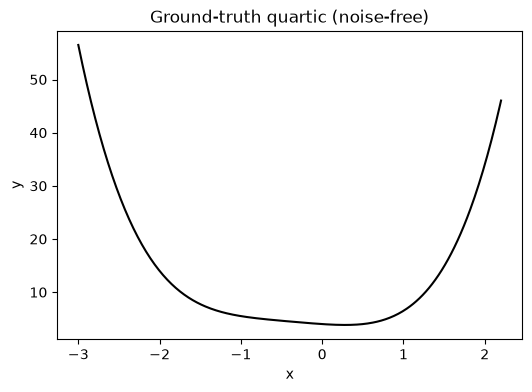

In [3]:
TRUE_COEFFICIENTS = np.array([1.0, 1.5, 1.0, -1.0, 4.0])  # a*x^4 + b*x^3 + c*x^2 + d*x + e
X_RANGE = (-3.0, 2.2)

def true_function(x):
    return np.polyval(TRUE_COEFFICIENTS, x)

def count_minima(coefficients):
    derivative = np.polyder(coefficients)
    second_derivative = np.polyder(derivative)
    roots = np.roots(derivative)
    real_roots = roots[np.isclose(roots.imag, 0.0)].real
    return sum(np.polyval(second_derivative, root) > 0 for root in real_roots)

n_minima = count_minima(TRUE_COEFFICIENTS)
assert n_minima == 1, f"Expected exactly one minimum, found {n_minima}."
print(f"Ground-truth quartic verified to have {n_minima} minimum over its domain.")

x_curve = np.linspace(*X_RANGE, 400)
with plt.ioff():
    ground_truth_figure, ground_truth_ax = plt.subplots(figsize=(6, 4))
ground_truth_ax.plot(x_curve, true_function(x_curve), color="black")
ground_truth_ax.set(title="Ground-truth quartic (noise-free)", xlabel="x", ylabel="y")
display(ground_truth_figure)
plt.close(ground_truth_figure)

## 4. Noisy Data Generation

Samples are drawn uniformly over the domain and evaluated on the true function, then perturbed with Gaussian noise. A fixed data-generation seed controls both the sampled locations and the underlying standard-normal noise draw. The noise-level control rescales that same draw, so the visible CV seed does not change the dataset.

In [4]:
N_POINTS = 60
DATA_GENERATION_SEED = 2024

def generate_dataset(noise_std, n_points=N_POINTS, x_range=X_RANGE):
    rng = np.random.default_rng(DATA_GENERATION_SEED)
    x = rng.uniform(x_range[0], x_range[1], size=n_points)
    y = true_function(x) + rng.normal(0.0, noise_std, size=n_points)
    order = np.argsort(x)
    return x[order], y[order]

x_demo, y_demo = generate_dataset(noise_std=1.0)
print(f"Generated {len(x_demo)} points | x range: [{x_demo.min():.2f}, {x_demo.max():.2f}]")

Generated 60 points | x range: [-2.98, 2.18]


## 5. Cross-Validation Splitters

Three schemes are supported: **k-fold** (random groups of held-out points), **leave-one-out** (every point is validated on individually), and **leave-one-cluster-out** (points are grouped by proximity in `x` with k-means, and one entire cluster is held out per fold). The cluster-based scheme tests generalization to a *region* of the input space rather than to scattered individual points. The CV seed controls K-fold shuffling and k-means initialization; leave-one-out is deterministic and therefore unaffected by it.

In [5]:
def get_cv_splits(cv_type, x, n_splits, cv_seed):
    if cv_type == "k-fold":
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=cv_seed)
        return list(splitter.split(x))
    if cv_type == "leave-one-out":
        return list(LeaveOneOut().split(x))
    if cv_type == "leave-one-cluster-out":
        clusters = KMeans(n_clusters=n_splits, random_state=cv_seed, n_init=10).fit_predict(x.reshape(-1, 1))
        return list(LeaveOneGroupOut().split(x, groups=clusters))
    raise ValueError(f"Unknown cv_type: {cv_type}")

demo_splits = get_cv_splits("leave-one-cluster-out", x_demo, n_splits=5, cv_seed=420)
print(f"leave-one-cluster-out produced {len(demo_splits)} folds")

leave-one-cluster-out produced 5 folds


## 6. Fitting and Metrics

Each fold fits a polynomial of the chosen degree on the training split and reports $R^2$, MAE, and MAPE on both the training and validation splits.

In [6]:
def fit_polynomial(x_train, y_train, degree):
    max_degree = max(len(x_train) - 1, 0)
    return np.polyfit(x_train, y_train, min(degree, max_degree))

def compute_metrics(y_true, y_pred):
    if len(y_true) < 2:
        return {"r2": np.nan, "mae": mean_absolute_error(y_true, y_pred), "mape": mean_absolute_percentage_error(y_true, y_pred)}
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "mape": mean_absolute_percentage_error(y_true, y_pred),
    }

## 7. Interactive Cross-Validation Explorer

Controls: CV type, number of folds/clusters, noise level, CV random seed, polynomial degree, and a fold index to manually cycle through folds. The CV seed affects only the validation split; the sampled data and underlying noise realization remain fixed. The left plot shows the data (train/validation colored to match the right plot) and the fitted curve against the true function. The right plot shows $R^2$, MAE, and MAPE for the currently selected fold.

In [7]:
TRAIN_COLOR = "#4c78a8"
VAL_COLOR = "#f58518"
FIT_COLOR = "#2ca02c"
TRUE_COLOR = "0.3"
EXTRAPOLATION_RANGE = (-5.0, 5.0)

cv_type_widget = Dropdown(options=["k-fold", "leave-one-out", "leave-one-cluster-out"], value="k-fold", description="CV type")
n_splits_widget = IntSlider(min=2, max=12, step=1, value=5, description="folds/clusters")
noise_widget = BoundedFloatText(min=0.0, max=4.0, step=0.1, value=1.0, description="noise std")
cv_seed_widget = BoundedIntText(min=0, max=9999, step=1, value=420, description="CV seed")
degree_widget = IntSlider(min=1, max=8, step=1, value=2, description="poly degree")
fold_widget = IntSlider(min=0, max=4, step=1, value=0, description="fold index")

def _current_split_count(cv_type, n_splits, cv_seed):
    x, _ = generate_dataset(noise_std=0.0)
    return len(get_cv_splits(cv_type, x, n_splits, cv_seed))

def _sync_controls(change=None):
    cv_type = cv_type_widget.value
    n_splits_widget.disabled = cv_type == "leave-one-out"
    total_folds = _current_split_count(cv_type, n_splits_widget.value, cv_seed_widget.value)
    fold_widget.max = max(total_folds - 1, 0)
    if fold_widget.value > fold_widget.max:
        fold_widget.value = fold_widget.max

for widget in (cv_type_widget, n_splits_widget, cv_seed_widget):
    widget.observe(_sync_controls, names="value")
_sync_controls()

def render(cv_type, n_splits, noise_std, cv_seed, degree, fold_index):
    x, y = generate_dataset(noise_std)
    splits = get_cv_splits(cv_type, x, n_splits, cv_seed)
    fold_index = min(fold_index, len(splits) - 1)
    train_idx, val_idx = splits[fold_index]

    coefficients = fit_polynomial(x[train_idx], y[train_idx], degree)
    val_prediction = np.polyval(coefficients, x[val_idx])
    train_metrics = compute_metrics(y[train_idx], np.polyval(coefficients, x[train_idx]))
    val_metrics = compute_metrics(y[val_idx], val_prediction)

    with plt.ioff():
        figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    x_curve = np.linspace(*EXTRAPOLATION_RANGE, 400)
    axes[0].plot(x_curve, true_function(x_curve), color=TRUE_COLOR, linestyle="--", label="true function")
    axes[0].plot(x_curve, np.polyval(coefficients, x_curve), color=FIT_COLOR, label=f"degree-{degree} fit")
    axes[0].axvspan(X_RANGE[0], X_RANGE[1], color="0.9", zorder=0, label="sampled domain")
    axes[0].scatter(x[train_idx], y[train_idx], color=TRAIN_COLOR, marker="o", label="train (actual)", zorder=3)
    axes[0].scatter(x[val_idx], y[val_idx], color=VAL_COLOR, marker="o", label="validation (actual)", zorder=3)
    axes[0].scatter(
        x[val_idx], val_prediction, facecolors="none", edgecolors=VAL_COLOR, marker="D", s=70, linewidths=1.5,
        label="validation (predicted)", zorder=4,
    )
    axes[0].set(xlabel="x", ylabel="y", xlim=EXTRAPOLATION_RANGE, title=f"Fold {fold_index + 1} of {len(splits)}")
    axes[0].legend(loc="upper center", fontsize=8)

    metric_names = ["r2", "mae", "mape"]
    positions = np.arange(len(metric_names))
    width = 0.35
    axes[1].bar(positions - width / 2, [train_metrics[m] for m in metric_names], width, color=TRAIN_COLOR, label="train")
    axes[1].bar(positions + width / 2, [val_metrics[m] for m in metric_names], width, color=VAL_COLOR, label="validation")
    axes[1].set_xticks(positions)
    axes[1].set_xticklabels(["R2", "MAE", "MAPE"])
    axes[1].axhline(0, color="0.7", linewidth=0.8)
    axes[1].set_title("Fold error metrics")
    axes[1].legend()

    figure.suptitle(f"CV type: {cv_type} | CV seed: {cv_seed} | noise std: {noise_std:.1f} | folds: {len(splits)}")
    figure.tight_layout()
    display(figure)
    plt.close(figure)

controls = VBox([
    HBox([cv_type_widget, n_splits_widget]),
    HBox([noise_widget, cv_seed_widget]),
    HBox([degree_widget, fold_widget]),
])
output = interactive_output(render, {
    "cv_type": cv_type_widget,
    "n_splits": n_splits_widget,
    "noise_std": noise_widget,
    "cv_seed": cv_seed_widget,
    "degree": degree_widget,
    "fold_index": fold_widget,
})
display(VBox([controls, output]))

## 8. Cross-Validation Validation Parity Plot

Each point is predicted using only the one fold model that never saw it during training, i.e. its out-of-fold validation prediction. No point is ever scored with a model trained on it. The left plot shows true vs. out-of-fold predicted value against a parity line; because each point has exactly one validation prediction per CV configuration, no per-point variance is shown here. The right plot shows the fitted polynomial coefficients across the same folds, so instability can be traced back to specific terms.

In [8]:
parity_cv_type_widget = Dropdown(options=["k-fold", "leave-one-out", "leave-one-cluster-out"], value="k-fold", description="CV type")
parity_n_splits_widget = IntSlider(min=2, max=12, step=1, value=5, description="folds/clusters")
parity_noise_widget = BoundedFloatText(min=0.0, max=4.0, step=0.1, value=1.0, description="noise std")
parity_cv_seed_widget = BoundedIntText(min=0, max=9999, step=1, value=420, description="CV seed")
parity_degree_widget = IntSlider(min=1, max=8, step=1, value=2, description="poly degree")

def _sync_parity_controls(change=None):
    parity_n_splits_widget.disabled = parity_cv_type_widget.value == "leave-one-out"

parity_cv_type_widget.observe(_sync_parity_controls, names="value")
_sync_parity_controls()

def render_parity(cv_type, n_splits, noise_std, cv_seed, degree):
    x, y = generate_dataset(noise_std)
    splits = get_cv_splits(cv_type, x, n_splits, cv_seed)

    out_of_fold_prediction = np.full(len(x), np.nan)
    coefficient_matrix = np.full((len(splits), degree + 1), np.nan)
    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        coefficients = fit_polynomial(x[train_idx], y[train_idx], degree)
        out_of_fold_prediction[val_idx] = np.polyval(coefficients, x[val_idx])
        coefficient_matrix[fold_idx, -len(coefficients):] = coefficients
    mean_coefficients = np.nanmean(coefficient_matrix, axis=0)
    std_coefficients = np.nanstd(coefficient_matrix, axis=0)

    with plt.ioff():
        figure, axes = plt.subplots(1, 2, figsize=(12, 5.5))

    limits = [min(y.min(), out_of_fold_prediction.min()), max(y.max(), out_of_fold_prediction.max())]
    axes[0].plot(limits, limits, color="0.4", linestyle="--", label="parity")
    axes[0].scatter(y, out_of_fold_prediction, color=VAL_COLOR, alpha=0.85, label="out-of-fold prediction")
    axes[0].set(
        xlabel="true y", ylabel="out-of-fold predicted y",
        title=f"Parity plot | {cv_type} | {len(splits)} folds | degree {degree} | CV seed {cv_seed}",
    )
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].legend(loc="upper left")

    term_labels = [f"x^{power}" for power in range(degree, 0, -1)] + ["intercept"]
    positions = np.arange(degree + 1)
    jitter_rng = np.random.default_rng(0)
    for term_idx in range(degree + 1):
        jitter = jitter_rng.uniform(-0.08, 0.08, size=len(splits))
        axes[1].scatter(
            positions[term_idx] + jitter, coefficient_matrix[:, term_idx],
            color=VAL_COLOR, alpha=0.6, s=18, zorder=2,
            label="per-fold value" if term_idx == 0 else None,
        )
    axes[1].errorbar(
        positions, mean_coefficients, yerr=std_coefficients, fmt="D",
        color=TRAIN_COLOR, ecolor=TRAIN_COLOR, elinewidth=1.5, capsize=4, markersize=6, zorder=3,
        label="mean \u00b1 std across folds",
    )
    axes[1].axhline(0, color="0.7", linewidth=0.8)
    axes[1].set_xticks(positions)
    axes[1].set_xticklabels(term_labels)
    axes[1].set(
        xlabel="polynomial term", ylabel="coefficient value",
        title=f"Fit coefficients across {len(splits)} folds",
    )
    axes[1].legend(loc="best")

    figure.tight_layout()
    display(figure)
    plt.close(figure)

parity_controls = VBox([
    HBox([parity_cv_type_widget, parity_n_splits_widget]),
    HBox([parity_noise_widget, parity_cv_seed_widget]),
    HBox([parity_degree_widget]),
])
parity_output = interactive_output(render_parity, {
    "cv_type": parity_cv_type_widget,
    "n_splits": parity_n_splits_widget,
    "noise_std": parity_noise_widget,
    "cv_seed": parity_cv_seed_widget,
    "degree": parity_degree_widget,
})
display(VBox([parity_controls, parity_output]))

## 9. PCA Loss Landscape and Coefficient Standard Errors

Each fold produces one vector of fitted polynomial coefficients. The left plot uses common PCA directions to project those vectors into two dimensions. Its fold-index slider selects which fold's training data define the RSS landscape; centering the plane on that fold's fitted coefficients places its least-squares solution at the origin. The right plot shows every fold's coefficient estimates with their within-fold OLS standard errors, calculated from the residual variance and $(X^T X)^{-1}$. These $\pm 1$ SE bars support visual comparisons with zero and with one another, but they are not 95% confidence intervals and the folds are not independent.

In [9]:
landscape_cv_type_widget = Dropdown(options=["k-fold", "leave-one-out", "leave-one-cluster-out"], value="k-fold", description="CV type")
landscape_n_splits_widget = IntSlider(min=2, max=12, step=1, value=5, description="folds/clusters")
landscape_noise_widget = BoundedFloatText(min=0.0, max=4.0, step=0.1, value=1.0, description="noise std")
landscape_cv_seed_widget = BoundedIntText(min=0, max=9999, step=1, value=420, description="CV seed")
landscape_degree_widget = IntSlider(min=1, max=8, step=1, value=2, description="poly degree")
landscape_fold_widget = IntSlider(min=0, max=4, step=1, value=0, description="fold index")

def _sync_landscape_controls(change=None):
    cv_type = landscape_cv_type_widget.value
    landscape_n_splits_widget.disabled = cv_type == "leave-one-out"
    total_folds = _current_split_count(cv_type, landscape_n_splits_widget.value, landscape_cv_seed_widget.value)
    landscape_fold_widget.max = max(total_folds - 1, 0)
    if landscape_fold_widget.value > landscape_fold_widget.max:
        landscape_fold_widget.value = landscape_fold_widget.max

for widget in (landscape_cv_type_widget, landscape_n_splits_widget, landscape_cv_seed_widget):
    widget.observe(_sync_landscape_controls, names="value")
_sync_landscape_controls()

def _padded_score_limits(values, fallback_span):
    value_span = np.ptp(values)
    if value_span < np.finfo(float).eps * 100:
        center = values.mean()
        return center - fallback_span / 2, center + fallback_span / 2
    padding = 0.3 * value_span
    return values.min() - padding, values.max() + padding

def _fit_polynomial_with_standard_errors(x_train, y_train, degree):
    coefficients = fit_polynomial(x_train, y_train, degree)
    design_matrix = np.vander(x_train, N=len(coefficients))
    residuals = y_train - design_matrix @ coefficients
    degrees_of_freedom = len(y_train) - len(coefficients)
    if degrees_of_freedom <= 0:
        return coefficients, np.full_like(coefficients, np.nan)
    residual_variance = np.sum(residuals ** 2) / degrees_of_freedom
    covariance = residual_variance * np.linalg.pinv(design_matrix.T @ design_matrix)
    standard_errors = np.sqrt(np.maximum(np.diag(covariance), 0.0))
    return coefficients, standard_errors

def render_coefficient_landscape(cv_type, n_splits, noise_std, cv_seed, degree, fold_index):
    x, y = generate_dataset(noise_std)
    splits = get_cv_splits(cv_type, x, n_splits, cv_seed)
    fold_index = min(fold_index, len(splits) - 1)

    fold_estimates = [
        _fit_polynomial_with_standard_errors(x[train_idx], y[train_idx], degree)
        for train_idx, _ in splits
    ]
    coefficient_matrix = np.vstack([estimate for estimate, _ in fold_estimates])
    standard_error_matrix = np.vstack([standard_error for _, standard_error in fold_estimates])
    mean_coefficients = coefficient_matrix.mean(axis=0)

    # PCA via SVD keeps the inverse mapping to polynomial-coefficient space explicit.
    centered_coefficients = coefficient_matrix - mean_coefficients
    _, singular_values, principal_axes = np.linalg.svd(centered_coefficients, full_matrices=False)
    principal_axes = principal_axes[:2]
    selected_coefficients = coefficient_matrix[fold_index]
    fold_scores = (coefficient_matrix - selected_coefficients) @ principal_axes.T
    mean_score = (mean_coefficients - selected_coefficients) @ principal_axes.T
    component_variance = singular_values[:2] ** 2
    total_variance = np.sum(singular_values ** 2)
    explained_ratio = component_variance / total_variance if total_variance > 0 else np.zeros(2)

    score_spans = np.ptp(fold_scores, axis=0)
    fallback_span = max(score_spans.max(), 0.05 * np.linalg.norm(mean_coefficients), 1e-3)
    pc1_limits = _padded_score_limits(fold_scores[:, 0], fallback_span)
    pc2_limits = _padded_score_limits(fold_scores[:, 1], fallback_span)
    pc1_grid, pc2_grid = np.meshgrid(
        np.linspace(*pc1_limits, 90),
        np.linspace(*pc2_limits, 90),
    )
    score_grid = np.column_stack([pc1_grid.ravel(), pc2_grid.ravel()])
    coefficient_grid = selected_coefficients + score_grid @ principal_axes

    selected_train_idx, _ = splits[fold_index]
    design_matrix = np.vander(x[selected_train_idx], N=degree + 1)
    residual_grid = y[selected_train_idx, None] - design_matrix @ coefficient_grid.T
    rss_grid = np.sum(residual_grid ** 2, axis=0).reshape(pc1_grid.shape)
    log_rss_grid = np.log10(np.maximum(rss_grid, np.finfo(float).tiny))

    with plt.ioff():
        figure, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    fold_cmap = plt.colormaps.get_cmap("plasma").resampled(len(splits))
    fold_colors = fold_cmap(np.arange(len(splits)))
    contours = axes[0].contourf(pc1_grid, pc2_grid, log_rss_grid, levels=24, cmap="viridis")
    axes[0].scatter(
        fold_scores[:, 0], fold_scores[:, 1], color=fold_colors, edgecolor="white",
        linewidth=0.7, s=36, zorder=3, label="all fold fits",
    )
    axes[0].scatter(
        0, 0, color=fold_colors[fold_index], marker="*", edgecolor="white",
        linewidth=0.9, s=150, zorder=5, label=f"selected fold {fold_index + 1}",
    )
    axes[0].scatter(
        mean_score[0], mean_score[1], color=TRAIN_COLOR, marker="D", edgecolor="white",
        linewidth=0.7, s=65, zorder=4, label="mean coefficients",
    )
    axes[0].set(
        xlabel=f"PC1 ({explained_ratio[0]:.1%} of fold variance)",
        ylabel=f"PC2 ({explained_ratio[1]:.1%} of fold variance)",
        title=f"Fold {fold_index + 1} training RSS landscape ({len(selected_train_idx)} points)",
    )
    axes[0].legend(loc="best")
    figure.colorbar(contours, ax=axes[0], label=f"log10 training RSS, fold {fold_index + 1}")

    term_labels = [f"x^{power}" for power in range(degree, 0, -1)] + ["intercept"]
    positions = np.arange(degree + 1)
    fold_offsets = np.linspace(-0.3, 0.3, len(splits)) if len(splits) > 1 else np.zeros(1)
    for current_fold in range(len(splits)):
        axes[1].errorbar(
            positions + fold_offsets[current_fold], coefficient_matrix[current_fold],
            yerr=standard_error_matrix[current_fold], fmt="o", color=fold_colors[current_fold],
            ecolor=fold_colors[current_fold], elinewidth=1.2, capsize=2.5, markersize=4, alpha=0.85,
            label="fold estimate \u00b1 OLS SE" if current_fold == 0 else None,
        )
    axes[1].axhline(0, color="0.7", linewidth=0.8)
    axes[1].set_xticks(positions)
    axes[1].set_xticklabels(term_labels)
    axes[1].set_xlim(-0.6, degree + 0.6)
    axes[1].set(
        xlabel="polynomial term", ylabel="coefficient value",
        title=f"Per-fold coefficient estimates across {len(splits)} folds",
    )
    axes[1].legend(loc="best")
    fold_color_scale = plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=1, vmax=len(splits)), cmap=fold_cmap,
    )
    figure.colorbar(fold_color_scale, ax=axes[1], label="fold number")

    figure.suptitle(f"{cv_type} | degree {degree} | CV seed {cv_seed} | noise std {noise_std:.1f}")
    figure.tight_layout()
    display(figure)
    plt.close(figure)

landscape_controls = VBox([
    HBox([landscape_cv_type_widget, landscape_n_splits_widget]),
    HBox([landscape_noise_widget, landscape_cv_seed_widget]),
    HBox([landscape_degree_widget, landscape_fold_widget]),
])
landscape_output = interactive_output(render_coefficient_landscape, {
    "cv_type": landscape_cv_type_widget,
    "n_splits": landscape_n_splits_widget,
    "noise_std": landscape_noise_widget,
    "cv_seed": landscape_cv_seed_widget,
    "degree": landscape_degree_widget,
    "fold_index": landscape_fold_widget,
})
display(VBox([landscape_controls, landscape_output]))

## 10. Fold Function Variance Plot

Every fold's fitted polynomial is plotted directly across the extended domain (the same $[-5, 5]$ extrapolation view used in Section 7), rather than reducing each fold to a single point or coefficient. Inside the shaded sampled region the curves should broadly agree; outside it they can diverge sharply, which is exactly the extrapolation risk a single validation score would not reveal. The bold curve and shaded band summarize the fold-to-fold mean and standard deviation.

In [10]:
fold_functions_cv_type_widget = Dropdown(options=["k-fold", "leave-one-out", "leave-one-cluster-out"], value="k-fold", description="CV type")
fold_functions_n_splits_widget = IntSlider(min=2, max=12, step=1, value=5, description="folds/clusters")
fold_functions_noise_widget = BoundedFloatText(min=0.0, max=4.0, step=0.1, value=1.0, description="noise std")
fold_functions_cv_seed_widget = BoundedIntText(min=0, max=9999, step=1, value=420, description="CV seed")
fold_functions_degree_widget = IntSlider(min=1, max=8, step=1, value=2, description="poly degree")

def _sync_fold_functions_controls(change=None):
    fold_functions_n_splits_widget.disabled = fold_functions_cv_type_widget.value == "leave-one-out"

fold_functions_cv_type_widget.observe(_sync_fold_functions_controls, names="value")
_sync_fold_functions_controls()

def render_fold_functions(cv_type, n_splits, noise_std, cv_seed, degree):
    x, y = generate_dataset(noise_std)
    splits = get_cv_splits(cv_type, x, n_splits, cv_seed)

    x_curve = np.linspace(*EXTRAPOLATION_RANGE, 400)
    fold_curves = np.full((len(splits), len(x_curve)), np.nan)
    for fold_idx, (train_idx, _) in enumerate(splits):
        coefficients = fit_polynomial(x[train_idx], y[train_idx], degree)
        fold_curves[fold_idx] = np.polyval(coefficients, x_curve)
    mean_curve = fold_curves.mean(axis=0)
    std_curve = fold_curves.std(axis=0)

    with plt.ioff():
        figure, ax = plt.subplots(figsize=(9, 5.5))
    ax.axvspan(X_RANGE[0], X_RANGE[1], color="0.9", zorder=0, label="sampled domain")
    ax.scatter(x, y, color="0.5", s=12, alpha=0.5, zorder=1, label="sampled data")
    for fold_idx in range(len(splits)):
        ax.plot(
            x_curve, fold_curves[fold_idx], color=VAL_COLOR, alpha=0.25, linewidth=1, zorder=2,
            label="per-fold fit" if fold_idx == 0 else None,
        )
    ax.fill_between(
        x_curve, mean_curve - std_curve, mean_curve + std_curve, color=TRAIN_COLOR, alpha=0.2, zorder=3,
        label="mean \u00b1 std across folds",
    )
    ax.plot(x_curve, mean_curve, color=TRAIN_COLOR, linewidth=2, zorder=4, label="mean fit across folds")
    ax.plot(x_curve, true_function(x_curve), color=TRUE_COLOR, linestyle="--", linewidth=1.5, zorder=5, label="true function")
    ax.set(
        xlabel="x", ylabel="y", xlim=EXTRAPOLATION_RANGE,
        title=f"Fold function variance | {cv_type} | {len(splits)} folds | degree {degree} | CV seed {cv_seed}",
    )
    ax.legend(loc="upper center", fontsize=8, ncol=2)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

fold_functions_controls = VBox([
    HBox([fold_functions_cv_type_widget, fold_functions_n_splits_widget]),
    HBox([fold_functions_noise_widget, fold_functions_cv_seed_widget]),
    HBox([fold_functions_degree_widget]),
])
fold_functions_output = interactive_output(render_fold_functions, {
    "cv_type": fold_functions_cv_type_widget,
    "n_splits": fold_functions_n_splits_widget,
    "noise_std": fold_functions_noise_widget,
    "cv_seed": fold_functions_cv_seed_widget,
    "degree": fold_functions_degree_widget,
})
display(VBox([fold_functions_controls, fold_functions_output]))